# Bucket 4 — Per-Pair IBKR Backtest

Isolates the **Bucket 4 v6 / IBKR** path from `Buckets1-4_v2.ipynb`:

- `run_bucket4_backtest_dynamic_h` (same engine as `Bucket_4_Backtest.ipynb` cell 14)
- IBKR / etf-dashboard borrow via `_v6_backtest_borrow_map`
- v6 portfolio **candidates** from `compute_v6_b4_pf_weight_dict`
- **§5–6** optional hedge grid (v6 / v7 / static) — not used for §7
- **§7** TR/VCR **continuous** cadence: **3 parameter sets** × **`dynamic_v6`** only


## 1. Setup (mirrors Buckets1-4_v2)

In [1]:
import importlib

import inspect

import pickle

import sys

import warnings

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import yaml



warnings.filterwarnings("ignore")

pd.options.display.float_format = "{:,.4f}".format



TRADING_DAYS = 252





def norm_sym(x: str) -> str:

    return str(x).strip().upper().replace(".", "-")





def find_repo_root() -> Path:

    here = Path.cwd().resolve()

    for p in (here, here.parent, *here.parents):

        if (p / "config" / "strategy_config.yml").exists() and (p / "scripts" / "gtp_sizing_mirror.py").exists():

            return p

    raise FileNotFoundError("Could not find repo root")





REPO_ROOT = find_repo_root()

NOTEBOOK_DIR = REPO_ROOT / "notebooks"

if str(REPO_ROOT) not in sys.path:

    sys.path.insert(0, str(REPO_ROOT))



with open(REPO_ROOT / "config" / "strategy_config.yml", "r", encoding="utf-8") as f:

    STRATEGY_CFG = yaml.safe_load(f) or {}

sleeves_cfg = (STRATEGY_CFG.get("portfolio") or {}).get("sleeves") or {}

b4_rules = (sleeves_cfg.get("inverse_decay_bucket4") or {}).get("rules") or {}

PARTIAL_HEDGE_YAML = float(b4_rules.get("partial_hedge_ratio", STRATEGY_CFG.get("b4_partial_hedge_ratio_default", 0.75)))



EXP = {

    "start_date": "2025-10-07",

    "end_date": None,

    "v6_b4_cache_path": str(NOTEBOOK_DIR / "v6_b4_gtp_cache.pkl"),

    "v6_b4_cache_rebuild": False,

    "v6_b4_allow_auto_bootstrap": True,

    "b4_resync_v6_rebal_weekly": True,

    "b4_weekly_warmup_bdays": 65,

    "b4_weekly_rebalance_freq": "W-FRI",

    "b4_weights_use_ibkr_uvix_borrow": True,

    "b4_drift_threshold_share_of_gross": 0.05,

    "b4_engine_fee_bps": 0.0,

    "b4_engine_slippage_bps": 20.0,

    "per_pair_initial_capital": 100_000.0,

    # dynamic_v7 hedge

    "v7_h_mid": 0.55,

    "v7_k_vcr": 1.0,

    "v7_smooth_alpha": 0.25,

    "v7_global_h_min": 0.30,

    "v7_global_h_max": 0.80,

    "v7_borrow_cap_h_max": 0.65,

    "v7_borrow_threshold": 0.50,

    # cadence study (section 7) — 3 continuous param sets × dynamic_v6 only

    "cadence_signal_window": 45,

    "cadence_lookahead_shift": 1,

    "cadence_hedge_method": "dynamic_v6",

    "continuous_param_sets": [

        {

            "id": "cont_balanced",

            "label": "Balanced",

            "base_days": 5.0,

            "k_tr": 2.0,

            "m_vcr": 2.5,

            "min_interval": 1,

            "max_interval": 12,

        },

        {

            "id": "cont_responsive",

            "label": "Responsive",

            "base_days": 4.0,

            "k_tr": 2.25,

            "m_vcr": 2.75,

            "min_interval": 1,

            "max_interval": 10,

        },

        {

            "id": "cont_aggressive",

            "label": "Aggressive",

            "base_days": 3.0,

            "k_tr": 2.75,

            "m_vcr": 3.25,

            "min_interval": 1,

            "max_interval": 7,

        },

    ],
    "v6_pf_params": {

        "decay_borrow_quad": 1,

        "borrow_linear_aversion": 3.0,

        "exclude_if_borrow_annual_gt": 0.9,

    },

}



SCREENED_PATH = REPO_ROOT / (STRATEGY_CFG.get("paths") or {}).get("screened_csv", "data/etf_screened_today.csv")

SCREENED = pd.read_csv(SCREENED_PATH)

for c in ("ETF", "Underlying"):

    SCREENED[c] = SCREENED[c].astype(str).map(norm_sym)



from scripts.gtp_dashboard_borrow import load_dashboard_borrow_avg_annual



DASHBOARD_BORROW_AVG, _ = load_dashboard_borrow_avg_annual()

if DASHBOARD_BORROW_AVG:

    _dash = SCREENED["ETF"].map(lambda s: DASHBOARD_BORROW_AVG.get(norm_sym(s), np.nan))

    for _col in ("borrow_current", "borrow_fee_annual", "borrow_avg_annual"):

        if _col not in SCREENED.columns:

            SCREENED[_col] = np.nan

        SCREENED[_col] = _dash.where(_dash.notna(), pd.to_numeric(SCREENED[_col], errors="coerce"))



BORROW_BY_ETF = {}

for _, r in SCREENED.iterrows():

    e = norm_sym(r["ETF"])

    b = r.get("borrow_avg_annual", np.nan)

    if not np.isfinite(b):

        b = r.get("borrow_current", np.nan)

    if np.isfinite(b):

        BORROW_BY_ETF[e] = float(max(0.0, b))



print(f"Repo: {REPO_ROOT}")

print(f"YAML partial_hedge_ratio: {PARTIAL_HEDGE_YAML:.2f}")


Repo: C:\Users\werdn\Documents\Investing\ls-algo
YAML partial_hedge_ratio: 0.75


## 2. Load v6 cache & IBKR borrow (Buckets1-4 cell 3)

In [2]:
import scripts.bucket4_dynamic_bt as _b4dyn
import scripts.bucket4_tail_portfolio as _b4tp
import scripts.v6_b4_pf_weights as _v6w

importlib.reload(_b4dyn)
importlib.reload(_b4tp)
importlib.reload(_v6w)

from scripts.bucket4_dynamic_bt import V6_OPT2_H_BASE, run_bucket4_backtest_dynamic_h
from scripts.bucket4_tail_portfolio import _etf_borrow_annual_actual
from scripts.v6_b4_pf_weights import V6PfParams, compute_v6_b4_pf_weight_dict


def _v6_backtest_borrow_map(symbols: list[str]) -> dict[str, float]:
    snap = globals().get("_V6_IBKR_BORROW_SNAPSHOT")
    out = {}
    for s in symbols:
        k = norm_sym(s)
        v = BORROW_BY_ETF.get(k)
        if v is None and isinstance(snap, dict):
            v = snap.get(k)
        if v is not None and np.isfinite(float(v)) and float(v) >= 0:
            out[k] = float(v)
    return out


def load_or_build_v6_globals() -> bool:
    cache_path = Path(EXP["v6_b4_cache_path"])
    if cache_path.exists() and not EXP.get("v6_b4_cache_rebuild"):
        try:
            with open(cache_path, "rb") as f:
                bundle = pickle.load(f)
            for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE", "v6_opt2_rebal_index", "_V6_IBKR_BORROW_SNAPSHOT"):
                if k in bundle and bundle[k] is not None:
                    globals()[k] = bundle[k]
            if all(globals().get(k) is not None for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE")):
                print(f"[v6] loaded {cache_path}")
                return True
        except Exception as e:
            print(f"[v6] cache load failed: {e}")
    if not EXP.get("v6_b4_allow_auto_bootstrap", True):
        return False
    from scripts.v6_bucket4_bootstrap_from_nb import ensure_v6_bucket4_globals_from_notebook

    print("[v6] bootstrapping from Bucket_4_Backtest.ipynb (slow)...")
    ensure_v6_bucket4_globals_from_notebook(globals(), repo_root=REPO_ROOT, screened_csv=SCREENED_PATH)
    etfs = {str(k[0]) for k, c in globals()["_V6_PAIR_CACHE"].items() if "skip_reason" not in c}
    etfs.add("UVIX")
    bundle = {
        "_V6_PAIR_CACHE": globals()["_V6_PAIR_CACHE"],
        "v6_opt2_h_daily_map": globals()["v6_opt2_h_daily_map"],
        "V6_OPT2_H_BASE": float(globals()["V6_OPT2_H_BASE"]),
        "v6_opt2_rebal_index": globals().get("v6_opt2_rebal_index"),
        "_V6_IBKR_BORROW_SNAPSHOT": _v6_backtest_borrow_map(sorted(etfs)),
    }
    with open(cache_path, "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[v6] cached {cache_path}")
    return True


assert load_or_build_v6_globals()

PAIR_CACHE = globals()["_V6_PAIR_CACHE"]
H_DAILY_MAP = globals()["v6_opt2_h_daily_map"]
H_BASE = float(globals().get("V6_OPT2_H_BASE", V6_OPT2_H_BASE))
REBAL_IX = pd.DatetimeIndex(globals()["v6_opt2_rebal_index"])

for c in PAIR_CACHE.values():
    if isinstance(c, dict) and isinstance(c.get("kw"), dict):
        c["kw"]["fee_bps"] = float(EXP["b4_engine_fee_bps"])
        c["kw"]["slippage_bps"] = float(EXP["b4_engine_slippage_bps"])

if EXP.get("b4_resync_v6_rebal_weekly"):
    from scripts.bucket4_weekly_opt2 import weekly_rebalance_dates

    u = set()
    for c in PAIR_CACHE.values():
        if isinstance(c, dict) and isinstance(c.get("prices"), pd.DataFrame):
            u.update(pd.to_datetime(c["prices"].index, errors="coerce").tolist())
    ix = pd.DatetimeIndex(sorted(u))
    REBAL_IX = weekly_rebalance_dates(ix, EXP["b4_weekly_rebalance_freq"], warmup_bdays=int(EXP["b4_weekly_warmup_bdays"]))
    print(f"[v6] rebal dates: {len(REBAL_IX)}")

_run_sig = inspect.signature(run_bucket4_backtest_dynamic_h)
_DRIFT_KW = (
    {"drift_threshold_share_of_gross": float(EXP["b4_drift_threshold_share_of_gross"])}
    if EXP.get("b4_drift_threshold_share_of_gross") is not None and "drift_threshold_share_of_gross" in _run_sig.parameters
    else {}
)

[v6] loaded C:\Users\werdn\Documents\Investing\ls-algo\notebooks\v6_b4_gtp_cache.pkl
[v6] rebal dates: 201


## 3. v6 portfolio candidates (Bucket 4)

In [3]:
_pf = EXP.get("v6_pf_params") or {}
p = V6PfParams(**{k: v for k, v in _pf.items() if k in V6PfParams.__dataclass_fields__})
_pf_kw = dict(
    pair_cache=PAIR_CACHE,
    v6_opt2_h_daily_map=H_DAILY_MAP,
    screened_csv=str(SCREENED_PATH),
    closes_broad=globals().get("closes_broad"),
    norm_sym=norm_sym,
    get_ibkr_borrow_map=_v6_backtest_borrow_map,
    opt2_h_base=H_BASE,
    params=p,
)
if "use_ibkr_uvix_borrow" in inspect.signature(compute_v6_b4_pf_weight_dict).parameters:
    _pf_kw["use_ibkr_uvix_borrow"] = bool(EXP.get("b4_weights_use_ibkr_uvix_borrow", True))
WEIGHTS, V6_DIAG, V6_META = compute_v6_b4_pf_weight_dict(**_pf_kw)
START_SIM = pd.Timestamp(V6_META["start_sim"])
CANDIDATE_KEYS = sorted(WEIGHTS.keys(), key=lambda k: (-WEIGHTS[k], f"{k[0]}/{k[1]}"))

cand_df = pd.DataFrame(
    [{"ETF": k[0], "Underlying": k[1], "v6_weight": WEIGHTS[k], "pair": f"{k[0]}/{k[1]}"} for k in CANDIDATE_KEYS]
)
print(f"start_sim={START_SIM.date()} | candidates={len(CANDIDATE_KEYS)} | decay={V6_META.get('decay_src_col')}")
display(cand_df)

start_sim=2025-10-07 | candidates=11 | decay=net_edge_p50_annual


,ETF,Underlying,v6_weight,pair
0,QBTZ,QBTS,0.1372,QBTZ/QBTS
1,ASTN,ASTS,0.1369,ASTN/ASTS
2,APLZ,APLD,0.1254,APLZ/APLD
3,IREZ,IREN,0.1230,IREZ/IREN
4,UVIX,SVIX,0.1128,UVIX/SVIX
5,SMZ,SMR,0.1117,SMZ/SMR
6,BEZ,BE,0.1082,BEZ/BE
7,CLSZ,CLSK,0.1019,CLSZ/CLSK
8,MSDD,MSTR,0.0154,MSDD/MSTR
9,CONI,COIN,0.0138,CONI/COIN


## 3b. TR/VCR signals (required for §7)

**Signals:** `etf-dashboard/data/vol_shape_history.json` (60d TR/VCR per ETF), shifted 1 day (no lookahead).

**Optional — dynamic_v7:** VCR-driven `h` in **[0.3, 0.8]** for the §5 hedge grid only (`h* = h_mid + k_vcr × (VCR − VCR_median)`).


signals: 11 sources={'history': 11} | v7 h series: 11


,pair,h_min,h_max,mean_h,min_h,max_h,corr_vcr_h
0,QBTZ/QBTS,0.30,0.65,0.54,0.50,0.60,0.96
1,ASTN/ASTS,0.30,0.65,0.55,0.55,0.57,nan
2,APLZ/APLD,0.30,0.80,0.55,0.55,0.60,0.56
3,IREZ/IREN,0.30,0.65,0.56,0.55,0.62,0.46
4,UVIX/SVIX,0.30,0.80,0.55,0.48,0.62,0.91
5,SMZ/SMR,0.30,0.80,0.55,0.55,0.55,nan
6,BEZ/BE,0.30,0.65,0.55,0.55,0.55,nan
7,CLSZ/CLSK,0.30,0.80,0.55,0.55,0.55,nan
8,MSDD/MSTR,0.30,0.80,0.61,0.53,0.72,0.97
9,CONI/COIN,0.30,0.65,0.52,0.46,0.65,0.89


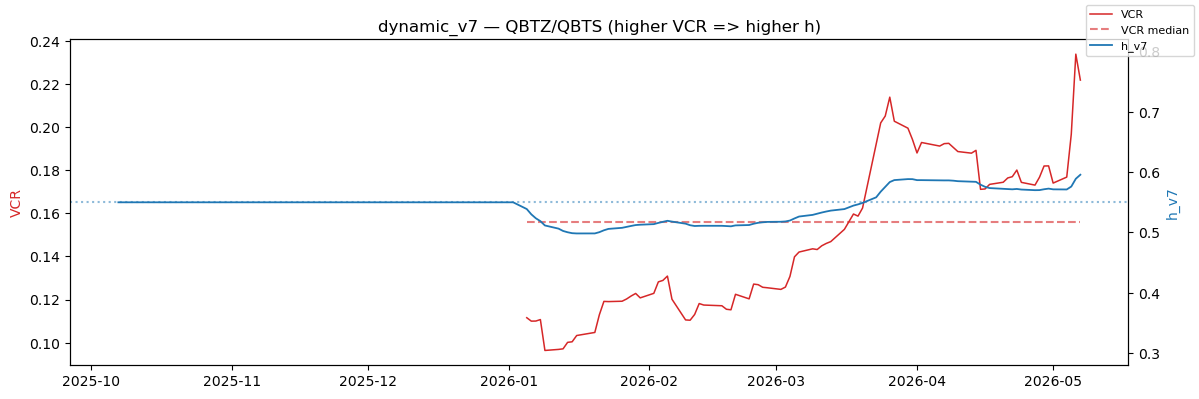

In [4]:
import scripts.bucket4_vol_shape_signals as _vss
import scripts.bucket4_hedge_v7 as _h7

importlib.reload(_vss)
importlib.reload(_h7)
from scripts.bucket4_vol_shape_signals import get_pair_signal, load_vol_shape_history
from scripts.bucket4_hedge_v7 import (
    V7_GLOBAL_H_MAX,
    V7_GLOBAL_H_MIN,
    build_h_v7_by_pair,
    default_v7_pair_bounds_from_screened,
    resolve_pair_h_bounds,
)

VOL_SHAPE_HISTORY_PATH = REPO_ROOT.parent / "etf-dashboard" / "data" / "vol_shape_history.json"
VS_HISTORY = load_vol_shape_history(VOL_SHAPE_HISTORY_PATH, norm_sym=norm_sym)

SIGNALS: dict[tuple[str, str], pd.DataFrame] = {}
_src_counts: dict[str, int] = {}
for key in CANDIDATE_KEYS:
    etf, und = key
    c = PAIR_CACHE.get(key) or {}
    prices_i = c.get("prices")
    if not isinstance(prices_i, pd.DataFrame) or prices_i.empty:
        continue
    cal = prices_i.loc[prices_i.index >= START_SIM].index
    # Use full b_px (incl. dates before START_SIM) so rolling TR/VCR has warmup
    und_px_full = prices_i["b_px"] if "b_px" in prices_i.columns else None
    sig = get_pair_signal(
        etf,
        und,
        cal,
        history=VS_HISTORY,
        underlying_prices=und_px_full,
        window=int(EXP["cadence_signal_window"]),
        lookahead_shift=int(EXP["cadence_lookahead_shift"]),
        prefer_underlying_recompute=True,
        norm_sym=norm_sym,
    )
    SIGNALS[key] = sig
    s = sig.attrs.get("signal_source", "?")
    _src_counts[s] = _src_counts.get(s, 0) + 1

V7_PAIR_BOUNDS = EXP.get("v7_pair_bounds")
if not V7_PAIR_BOUNDS:
    V7_PAIR_BOUNDS = default_v7_pair_bounds_from_screened(
        SCREENED,
        CANDIDATE_KEYS,
        global_h_min=float(EXP["v7_global_h_min"]),
        global_h_max=float(EXP["v7_global_h_max"]),
        high_borrow_cap_h_max=float(EXP["v7_borrow_cap_h_max"]),
        borrow_threshold=float(EXP["v7_borrow_threshold"]),
        norm_sym=norm_sym,
    )

H_V7_BY_PAIR = build_h_v7_by_pair(
    SIGNALS,
    PAIR_CACHE,
    start_sim=START_SIM,
    pair_bounds=V7_PAIR_BOUNDS,
    h_mid=float(EXP["v7_h_mid"]),
    k_vcr=float(EXP["v7_k_vcr"]),
    global_h_min=float(EXP["v7_global_h_min"]),
    global_h_max=float(EXP["v7_global_h_max"]),
    smooth_alpha=float(EXP["v7_smooth_alpha"]),
    norm_sym=norm_sym,
)

bounds_rows = []
for key in CANDIDATE_KEYS:
    if key not in H_V7_BY_PAIR:
        continue
    lo, hi = resolve_pair_h_bounds(
        key[0], key[1], pair_bounds=V7_PAIR_BOUNDS,
        global_h_min=float(EXP["v7_global_h_min"]), global_h_max=float(EXP["v7_global_h_max"]), norm_sym=norm_sym,
    )
    h = H_V7_BY_PAIR[key]
    vcr = SIGNALS[key]["vcr"].reindex(h.index).ffill()
    bounds_rows.append({
        "pair": f"{key[0]}/{key[1]}",
        "h_min": lo, "h_max": hi,
        "mean_h": float(h.mean()), "min_h": float(h.min()), "max_h": float(h.max()),
        "corr_vcr_h": float(vcr.corr(h)) if vcr.notna().sum() > 5 else np.nan,
    })

_sig_diag = []
for key in CANDIDATE_KEYS:
    sig = SIGNALS.get(key)
    if sig is None:
        continue
    tr_ok = sig["tr"].notna()
    _sig_diag.append({
        "pair": f"{key[0]}/{key[1]}",
        "source": sig.attrs.get("signal_source"),
        "cal_days": len(sig),
        "tr_valid": int(tr_ok.sum()),
        "first_tr": tr_ok.idxmax() if tr_ok.any() else None,
    })

print(f"signals: {len(SIGNALS)} sources={_src_counts} | v7 h series: {len(H_V7_BY_PAIR)}")
display(pd.DataFrame(_sig_diag))
display(pd.DataFrame(bounds_rows).style.format({"h_min": "{:.2f}", "h_max": "{:.2f}", "mean_h": "{:.2f}", "min_h": "{:.2f}", "max_h": "{:.2f}", "corr_vcr_h": "{:.2f}"}))

# Top-weight pair: VCR vs h_v7
_top = CANDIDATE_KEYS[0]
if _top in H_V7_BY_PAIR:
    fig, ax1 = plt.subplots(figsize=(12, 4))
    sig = SIGNALS[_top]
    h = H_V7_BY_PAIR[_top]
    ax1.plot(sig.index, sig["vcr"], color="tab:red", lw=1.1, label="VCR")
    ax1.plot(sig.index, sig["vcr_med"], color="tab:red", ls="--", alpha=0.6, label="VCR median")
    ax1.set_ylabel("VCR", color="tab:red")
    ax2 = ax1.twinx()
    ax2.plot(h.index, h.values, color="tab:blue", lw=1.3, label="h_v7")
    ax2.axhline(float(EXP["v7_h_mid"]), color="tab:blue", ls=":", alpha=0.5)
    ax2.set_ylim(float(EXP["v7_global_h_min"]) - 0.02, float(EXP["v7_global_h_max"]) + 0.02)
    ax2.set_ylabel("h_v7", color="tab:blue")
    ax1.set_title(f"dynamic_v7 — {_top[0]}/{_top[1]} (higher VCR => higher h)")
    fig.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Hedge methods & per-pair engine

Each method supplies a daily **h** series for `run_bucket4_backtest_dynamic_h`:

`target_share_a = 1 / (1 + h × |β_inverse|)` (both legs short).

| Method | Description |
|--------|-------------|
| `dynamic_v7` | **Primary:** VCR vs median → h ∈ [0.3, 0.8], pair bounds |
| `dynamic_v6` | Legacy Opt-2 cross-sectional hedge from v6 cache |
| `static_h_0.55` | Constant anchor at `v7_h_mid` |

In [5]:
def build_hedge_methods() -> dict[str, str]:
    return {
        "dynamic_v7": "VCR-driven h [0.3,0.8], pair bounds",
        "dynamic_v6": "Opt-2 dynamic h (legacy)",
        "static_h_0.55": f"h={float(EXP.get('v7_h_mid', 0.55)):.2f} anchor",
    }


def resolve_h_series(method: str, key: tuple[str, str], price_index: pd.DatetimeIndex) -> pd.Series:
    etf_sym, und_sym = key
    if method == "dynamic_v7":
        ser = H_V7_BY_PAIR.get(key)
        if ser is None or getattr(ser, "empty", True):
            raise KeyError(f"no v7 h for {key}")
        return ser.reindex(price_index).ffill().fillna(float(EXP["v7_h_mid"]))
    if method == "dynamic_v6":
        ser = H_DAILY_MAP.get(norm_sym(und_sym))
        if ser is None or getattr(ser, "empty", True):
            raise KeyError(f"no v6 h series for {und_sym}")
        return ser.reindex(price_index).ffill().fillna(H_BASE)
    if method == "static_yaml":
        h_const = float(PARTIAL_HEDGE_YAML)
    elif method.startswith("static_h_"):
        h_const = float(method.split("_")[-1])
    else:
        raise ValueError(method)
    return pd.Series(h_const, index=price_index, dtype=float)


def _uvix_borrow_base() -> float | None:
    if not EXP.get("b4_weights_use_ibkr_uvix_borrow", True):
        return None
    try:
        m = _v6_backtest_borrow_map(["UVIX"])
        v = m.get("UVIX")
        if v is not None and np.isfinite(float(v)) and float(v) > 0:
            return float(v)
    except Exception:
        pass
    return None


UVIX_BORROW = _uvix_borrow_base()


def run_single_pair_backtest(
    key: tuple[str, str],
    method: str,
    *,
    initial_capital: float | None = None,
) -> pd.DataFrame | None:
    """One pair, one hedge method — mirrors aggregate_tail_risk_weighted_portfolio inner loop."""
    if key not in PAIR_CACHE or "skip_reason" in PAIR_CACHE[key]:
        return None
    etf_sym, und_sym = key
    c = PAIR_CACHE[key]
    prices_i = c["prices"].loc[c["prices"].index >= START_SIM]
    if prices_i.empty:
        return None
    kw = dict(c["kw"])
    kw["initial_capital"] = float(initial_capital or EXP["per_pair_initial_capital"])
    kw["borrow_a_annual"] = _etf_borrow_annual_actual(
        etf_sym, kw, uvix_borrow_annual_base=UVIX_BORROW, norm_sym=norm_sym
    )
    kw.update(_DRIFT_KW)
    h_d = resolve_h_series(method, key, prices_i.index)
    pair_rebal = REBAL_IX.intersection(prices_i.index)
    if len(pair_rebal) == 0:
        pair_rebal = pd.DatetimeIndex([prices_i.index[0]])
    return run_bucket4_backtest_dynamic_h(prices_i, h_d, pair_rebal, **kw)


def pair_metrics(bt: pd.DataFrame) -> dict[str, float]:
    """CAGR / vol / max_dd on standalone sub-account equity (same span logic as Buckets1-4)."""
    nav = bt["equity"].astype(float)
    rets = nav.pct_change().iloc[1:].dropna()
    span_days = max(int((nav.index[-1] - nav.index[0]).days), 0)
    years = max(span_days / 365.25, 1.0 / 365.25)
    n0, n1 = float(nav.iloc[0]), float(nav.iloc[-1])
    cagr = (n1 / n0) ** (1.0 / years) - 1.0 if n0 > 1e-9 else np.nan
    if len(rets) > 2:
        sd = float(rets.std(ddof=1))
        vol = sd * np.sqrt(TRADING_DAYS) if sd > 1e-18 else np.nan
    else:
        vol = np.nan
    dd = nav / nav.cummax() - 1.0
    return {"CAGR": cagr, "vol": vol, "max_dd": float(dd.min()), "final_equity": n1}


HEDGE_METHODS = build_hedge_methods()
print("Hedge methods:", list(HEDGE_METHODS.keys()))

Hedge methods: ['dynamic_v7', 'dynamic_v6', 'static_h_0.55']


## 5. Run grid (all pairs × hedge methods)

*Optional — not used for §7. §7 uses **dynamic_v6** only with three continuous cadence presets.*


In [6]:
rows = []
bt_store: dict[tuple[str, str, str], pd.DataFrame] = {}

for key in CANDIDATE_KEYS:
    pair_lab = f"{key[0]}/{key[1]}"
    for method in HEDGE_METHODS:
        try:
            bt = run_single_pair_backtest(key, method)
        except Exception as ex:
            print(f"SKIP {pair_lab} {method}: {ex}")
            continue
        if bt is None or bt.empty:
            continue
        m = pair_metrics(bt)
        bt_store[(pair_lab, method)] = bt
        rows.append(
            {
                "pair": pair_lab,
                "ETF": key[0],
                "Underlying": key[1],
                "hedge_method": method,
                "hedge_label": HEDGE_METHODS[method],
                "v6_weight": WEIGHTS[key],
                **m,
                "mean_h": float(bt["h_used"].mean()) if "h_used" in bt.columns else np.nan,
                "borrow_paid": float(bt["borrow_cost"].sum()) if "borrow_cost" in bt.columns else np.nan,
            }
        )

RESULTS = pd.DataFrame(rows)
if RESULTS.empty:
    raise RuntimeError("No backtests completed — check v6 cache and candidates.")

RESULTS = RESULTS.sort_values(["pair", "hedge_method"]).reset_index(drop=True)
print(f"Completed {len(RESULTS)} runs ({len(CANDIDATE_KEYS)} pairs × {len(HEDGE_METHODS)} methods)")
display(
    RESULTS[
        ["pair", "hedge_method", "CAGR", "vol", "max_dd", "mean_h", "v6_weight", "borrow_paid"]
    ].style.format({"CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}", "mean_h": "{:.3f}", "v6_weight": "{:.3f}"})
)

Completed 33 runs (11 pairs × 3 methods)


,pair,hedge_method,CAGR,vol,max_dd,mean_h,v6_weight,borrow_paid
0,APLZ/APLD,dynamic_v6,234.56%,50.50%,-14.26%,0.626,0.125,4937.251821
1,APLZ/APLD,dynamic_v7,258.11%,68.59%,-19.38%,0.555,0.125,5320.261927
2,APLZ/APLD,static_h_0.55,264.22%,68.73%,-19.38%,0.550,0.125,5335.998470
3,ASTN/ASTS,dynamic_v6,-10.11%,32.97%,-12.25%,0.687,0.137,5083.431701
4,ASTN/ASTS,dynamic_v7,-23.05%,45.15%,-18.16%,0.550,0.137,5643.524318
5,ASTN/ASTS,static_h_0.55,-23.04%,45.15%,-18.16%,0.550,0.137,5643.524318
6,BEZ/BE,dynamic_v6,119.57%,27.91%,-6.69%,0.681,0.108,7251.481951
7,BEZ/BE,dynamic_v7,197.63%,46.74%,-11.48%,0.550,0.108,8324.526157
8,BEZ/BE,static_h_0.55,197.63%,46.74%,-11.48%,0.550,0.108,8324.526157
9,CLSZ/CLSK,dynamic_v6,267.72%,32.75%,-6.59%,0.538,0.102,1138.834540


## 6. Plots — CAGR / vol / max drawdown by pair

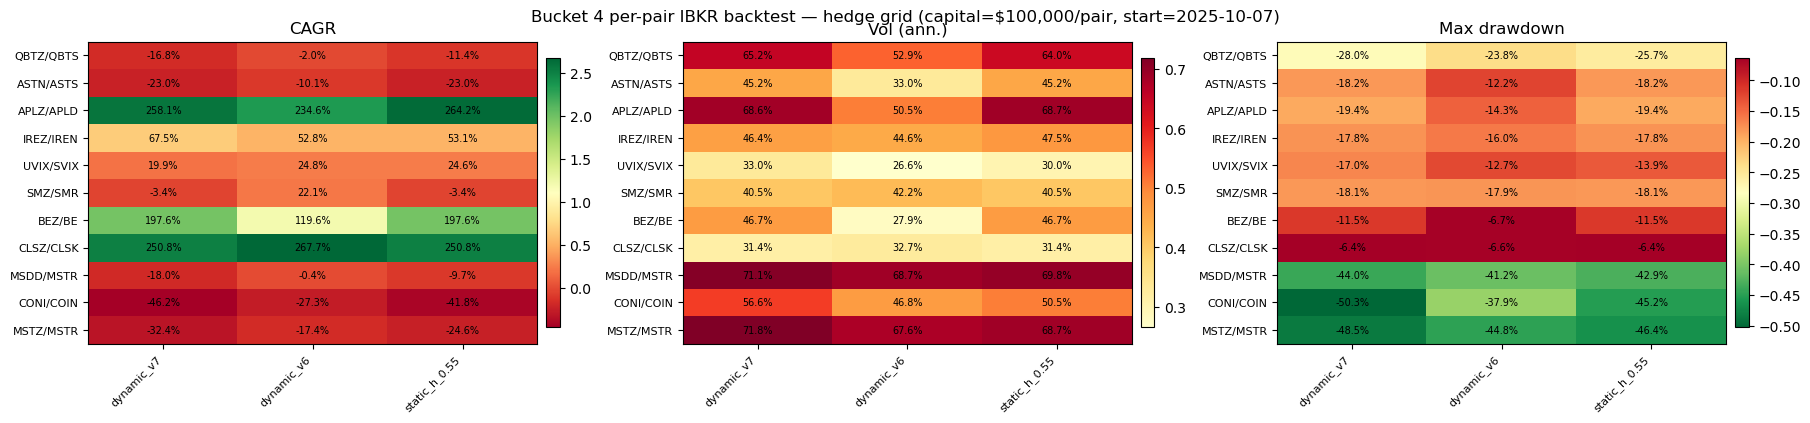

In [7]:
pairs_order = [f"{k[0]}/{k[1]}" for k in CANDIDATE_KEYS]
methods_order = list(HEDGE_METHODS.keys())


def metric_pivot(metric: str) -> pd.DataFrame:
    p = RESULTS.pivot(index="pair", columns="hedge_method", values=metric)
    return p.reindex(index=pairs_order, columns=methods_order)


pv_cagr = metric_pivot("CAGR")
pv_vol = metric_pivot("vol")
pv_dd = metric_pivot("max_dd")

fig, axes = plt.subplots(1, 3, figsize=(18, max(4.0, 0.35 * len(pairs_order))), constrained_layout=True)
for ax, pv, title, cmap in zip(
    axes,
    [pv_cagr, pv_vol, pv_dd],
    ["CAGR", "Vol (ann.)", "Max drawdown"],
    ["RdYlGn", "YlOrRd", "RdYlGn_r"],
):
    data = pv.astype(float).values
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(methods_order, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pairs_order)))
    ax.set_yticklabels(pairs_order, fontsize=8)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=7, color="black")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
fig.suptitle(
    f"Bucket 4 per-pair IBKR backtest — hedge grid (capital=${EXP['per_pair_initial_capital']:,.0f}/pair, start={START_SIM.date()})",
    fontsize=12,
    y=1.02,
)
plt.show()

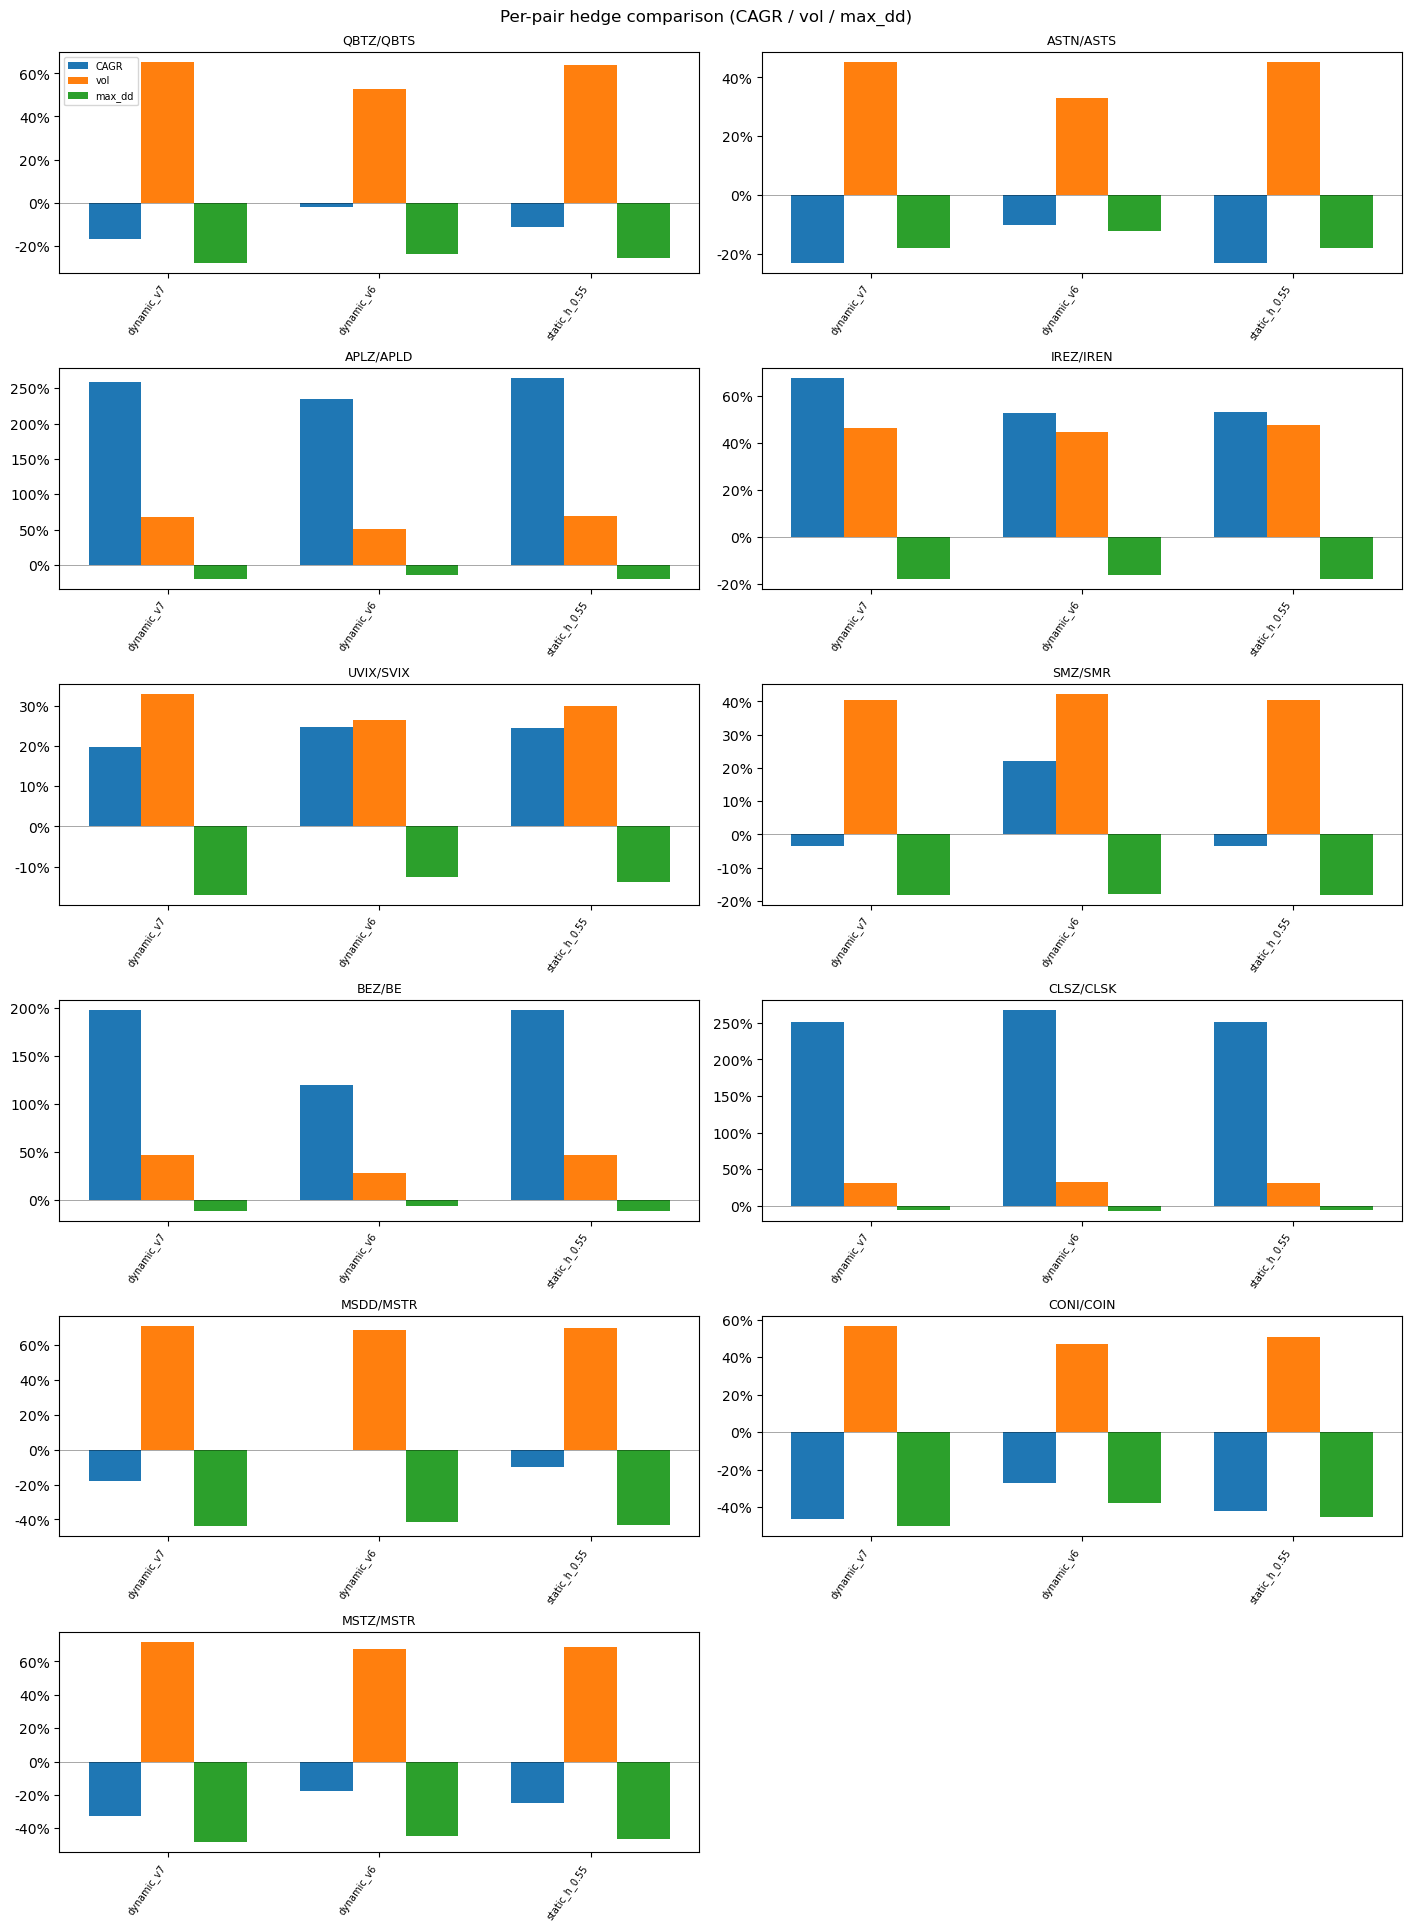

In [8]:
n_pairs = len(pairs_order)
ncols = 2
nrows = int(np.ceil(n_pairs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), constrained_layout=True)
axes_flat = np.atleast_1d(axes).ravel()
x = np.arange(len(methods_order))
w = 0.25

for i, pair_lab in enumerate(pairs_order):
    ax = axes_flat[i]
    sub = RESULTS[RESULTS["pair"] == pair_lab].set_index("hedge_method").reindex(methods_order)
    cagr = sub["CAGR"].astype(float).values
    vol = sub["vol"].astype(float).values
    dd = sub["max_dd"].astype(float).values
    ax.bar(x - w, cagr, width=w, label="CAGR")
    ax.bar(x, vol, width=w, label="vol")
    ax.bar(x + w, dd, width=w, label="max_dd")
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_order, rotation=55, ha="right", fontsize=7)
    ax.set_title(pair_lab, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Per-pair hedge comparison (CAGR / vol / max_dd)", fontsize=12)
plt.show()

Best CAGR hedge per pair:


,pair,hedge_method,CAGR,vol,max_dd
0,APLZ/APLD,static_h_0.55,264.22%,68.73%,-19.38%
1,ASTN/ASTS,dynamic_v6,-10.11%,32.97%,-12.25%
2,BEZ/BE,dynamic_v7,197.63%,46.74%,-11.48%
3,CLSZ/CLSK,dynamic_v6,267.72%,32.75%,-6.59%
4,CONI/COIN,dynamic_v6,-27.26%,46.79%,-37.94%
5,IREZ/IREN,dynamic_v7,67.50%,46.35%,-17.75%
6,MSDD/MSTR,dynamic_v6,-0.40%,68.72%,-41.18%
7,MSTZ/MSTR,dynamic_v6,-17.42%,67.57%,-44.78%
8,QBTZ/QBTS,dynamic_v6,-1.98%,52.91%,-23.81%
9,SMZ/SMR,dynamic_v6,22.14%,42.21%,-17.91%


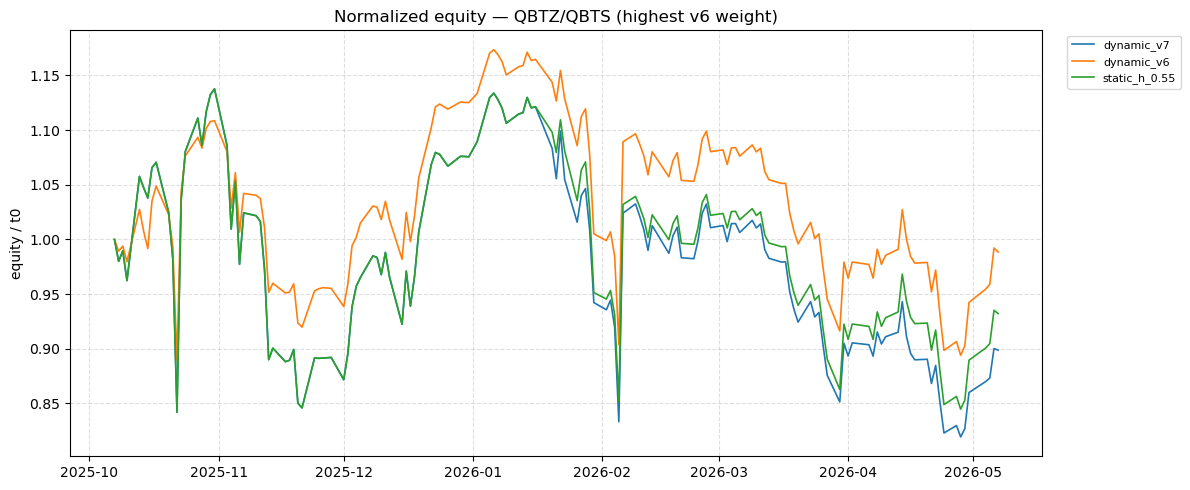

In [9]:
best = (
    RESULTS.sort_values("CAGR", ascending=False)
    .groupby("pair", as_index=False)
    .first()[["pair", "hedge_method", "CAGR", "vol", "max_dd"]]
)
print("Best CAGR hedge per pair:")
display(best.style.format({"CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}"}))

top_pair = pairs_order[0]
fig, ax = plt.subplots(figsize=(12, 5))
for method in methods_order:
    bt = bt_store.get((top_pair, method))
    if bt is None:
        continue
    eq = bt["equity"].astype(float)
    norm = eq / float(eq.iloc[0]) if float(eq.iloc[0]) > 1e-9 else eq
    ax.plot(norm.index, norm.values, lw=1.2, label=method)
ax.set_title(f"Normalized equity — {top_pair} (highest v6 weight)")
ax.set_ylabel("equity / t0")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Continuous cadence — 3 parameter sets × dynamic_v6

**Hedge (fixed):** `dynamic_v6` — Opt-2 daily `h` from v6 cache.

**Cadence:** TR/VCR interval only (no `every_5d`, no leg-drift policies):

`interval = clip(round(base_days / (1 + k_tr*(TR-1) + m_vcr*(VCR-VCR_med))), min_interval, max_interval)` trading days.

| Variant id | Label | Role |
|------------|-------|------|
| `cont_balanced` | Balanced | Moderate rebalancing |
| `cont_responsive` | Responsive | Current tuned default |
| `cont_aggressive` | Aggressive | Fastest schedule |

Edit presets in `EXP["continuous_param_sets"]` (§1).


In [ ]:
from scripts.bucket4_vol_shape_signals import (
    policy_continuous_interval,
    rebalance_cadence_stats,
)

CADENCE_HEDGE = "dynamic_v6"
if str(EXP.get("cadence_hedge_method", CADENCE_HEDGE)) != CADENCE_HEDGE:
    raise ValueError("§7 requires cadence_hedge_method='dynamic_v6'")

CONTINUOUS_PARAM_SETS: list[dict] = list(EXP.get("continuous_param_sets") or [])
if len(CONTINUOUS_PARAM_SETS) != 3:
    raise ValueError("EXP['continuous_param_sets'] must contain exactly 3 dicts")
VARIANT_ORDER = [str(s["id"]) for s in CONTINUOUS_PARAM_SETS]
VARIANT_BY_ID = {str(s["id"]): s for s in CONTINUOUS_PARAM_SETS}


def _cont_kwargs_for(variant_id: str) -> dict:
    spec = VARIANT_BY_ID[variant_id]
    return dict(
        base_days=float(spec["base_days"]),
        k_tr=float(spec["k_tr"]),
        m_vcr=float(spec["m_vcr"]),
        min_interval=int(spec["min_interval"]),
        max_interval=int(spec["max_interval"]),
    )


def variant_label(variant_id: str) -> str:
    return str(VARIANT_BY_ID[variant_id].get("label", variant_id))


def build_continuous_rebal_dates(
    key: tuple[str, str], cal: pd.DatetimeIndex, variant_id: str
) -> pd.DatetimeIndex:
    sig = SIGNALS.get(key)
    return policy_continuous_interval(cal, sig, **_cont_kwargs_for(variant_id))[0]


def _pair_kw(key: tuple[str, str]) -> dict:
    etf_sym, _ = key
    kw = dict(PAIR_CACHE[key]["kw"])
    kw["initial_capital"] = float(EXP["per_pair_initial_capital"])
    kw["borrow_a_annual"] = _etf_borrow_annual_actual(
        etf_sym, kw, uvix_borrow_annual_base=UVIX_BORROW, norm_sym=norm_sym
    )
    return kw


def run_continuous_variant(key: tuple[str, str], variant_id: str) -> pd.DataFrame | None:
    if key not in PAIR_CACHE or "skip_reason" in PAIR_CACHE[key]:
        return None
    prices_i = PAIR_CACHE[key]["prices"].loc[PAIR_CACHE[key]["prices"].index >= START_SIM]
    if prices_i.empty:
        return None
    cal = prices_i.index
    kw = _pair_kw(key)
    kw.pop("opt2_h_base", H_BASE)
    h_d = resolve_h_series(CADENCE_HEDGE, key, prices_i.index)
    rd = build_continuous_rebal_dates(key, cal, variant_id).intersection(cal)
    if len(rd) == 0:
        rd = pd.DatetimeIndex([cal[0]])
    return run_bucket4_backtest_dynamic_h(prices_i, h_d, rd, **kw)


if not SIGNALS:
    raise RuntimeError("Run section 3b (TR/VCR signals) before section 7.")
print(f"§7 continuous sweep | hedge={CADENCE_HEDGE} | slippage={EXP['b4_engine_slippage_bps']} bps")
for vid in VARIANT_ORDER:
    spec = VARIANT_BY_ID[vid]
    print(
        f"  {vid} ({spec.get('label', '')}): base={spec['base_days']} k_tr={spec['k_tr']} "
        f"m_vcr={spec['m_vcr']} min={spec['min_interval']} max={spec['max_interval']}"
    )


### 7.1 Run sweep (pairs × 3 continuous variants)


In [ ]:
def _cadence_metrics(bt: pd.DataFrame) -> dict[str, float]:
    out = pair_metrics(bt)
    reb = bt.index[bt["rebalance"].astype(bool)] if "rebalance" in bt.columns else pd.DatetimeIndex([])
    out.update(rebalance_cadence_stats(reb))
    out["borrow_paid"] = float(bt["borrow_cost"].sum()) if "borrow_cost" in bt.columns else np.nan
    out["cost_paid"] = float(bt["rebalance_fee"].sum()) if "rebalance_fee" in bt.columns else np.nan
    return out


freq_rows: list[dict] = []
freq_bt: dict[tuple[str, str], pd.DataFrame] = {}
freq_dates: dict[tuple[str, str], pd.DatetimeIndex] = {}

for key in CANDIDATE_KEYS:
    pair_lab = f"{key[0]}/{key[1]}"
    c = PAIR_CACHE.get(key) or {}
    prices_i = c.get("prices")
    if not isinstance(prices_i, pd.DataFrame) or prices_i.empty:
        continue
    cal = prices_i.loc[prices_i.index >= START_SIM].index
    for variant_id in VARIANT_ORDER:
        spec = VARIANT_BY_ID[variant_id]
        try:
            freq_dates[(pair_lab, variant_id)] = build_continuous_rebal_dates(key, cal, variant_id)
            bt = run_continuous_variant(key, variant_id)
        except Exception as ex:
            print(f"SKIP {pair_lab} {variant_id}: {ex}")
            continue
        if bt is None or bt.empty:
            continue
        freq_bt[(pair_lab, variant_id)] = bt
        freq_rows.append(
            {
                "pair": pair_lab,
                "ETF": key[0],
                "Underlying": key[1],
                "variant": variant_id,
                "variant_label": str(spec.get("label", variant_id)),
                "base_days": float(spec["base_days"]),
                "k_tr": float(spec["k_tr"]),
                "m_vcr": float(spec["m_vcr"]),
                "min_interval": int(spec["min_interval"]),
                "max_interval": int(spec["max_interval"]),
                "v6_weight": WEIGHTS[key],
                **_cadence_metrics(bt),
            }
        )

FREQ = pd.DataFrame(freq_rows)
if FREQ.empty:
    raise RuntimeError("No cadence backtests completed.")
FREQ["ret_vol"] = FREQ["CAGR"] / FREQ["vol"].replace(0.0, np.nan)
FREQ = FREQ.sort_values(["pair", "variant"]).reset_index(drop=True)
print(
    f"Completed {len(FREQ)} runs ({FREQ['pair'].nunique()} pairs × {len(VARIANT_ORDER)} variants), "
    f"hedge={CADENCE_HEDGE}, slippage={EXP['b4_engine_slippage_bps']} bps"
)
display(
    FREQ[
        [
            "pair",
            "variant",
            "variant_label",
            "CAGR",
            "vol",
            "max_dd",
            "n_rebalances",
            "mean_interval_days",
            "cost_paid",
        ]
    ].style.format(
        {
            "CAGR": "{:.2%}",
            "vol": "{:.2%}",
            "max_dd": "{:.2%}",
            "n_rebalances": "{:.0f}",
            "mean_interval_days": "{:.1f}",
            "cost_paid": "{:,.0f}",
        }
    )
)


### 7.2 Per-security results (each pair × 3 variants)


In [ ]:
freq_pairs_order = [f"{k[0]}/{k[1]}" for k in CANDIDATE_KEYS if f"{k[0]}/{k[1]}" in set(FREQ["pair"])]


def freq_pivot(metric: str, column: str = "variant") -> pd.DataFrame:
    pv = FREQ.pivot(index="pair", columns=column, values=metric)
    return pv.reindex(index=freq_pairs_order, columns=VARIANT_ORDER)


print("CAGR by pair × variant")
display(
    freq_pivot("CAGR").style.format("{:.2%}", na_rep="—").set_caption("Per-security CAGR")
)
print("Max drawdown by pair × variant")
display(
    freq_pivot("max_dd").style.format("{:.2%}", na_rep="—").set_caption("Per-security max DD")
)

best_rows = []
for pair in freq_pairs_order:
    sub = FREQ[FREQ["pair"] == pair]
    if sub.empty:
        continue
    bc = sub.loc[sub["CAGR"].idxmax()]
    brv = sub.loc[sub["ret_vol"].idxmax()]
    bdd = sub.loc[sub["max_dd"].idxmax()]
    best_rows.append(
        {
            "pair": pair,
            "best_CAGR_variant": bc["variant"],
            "best_CAGR": bc["CAGR"],
            "best_ret_vol_variant": brv["variant"],
            "best_ret_vol": brv["ret_vol"],
            "best_max_dd_variant": bdd["variant"],
            "best_max_dd": bdd["max_dd"],
        }
    )
BEST_BY_PAIR = pd.DataFrame(best_rows)
print("Best variant per pair (by metric)")
display(
    BEST_BY_PAIR.style.format(
        {
            "best_CAGR": "{:.2%}",
            "best_ret_vol": "{:.2f}",
            "best_max_dd": "{:.2%}",
        }
    )
)


### 7.3 Aggregate mean results (equal-weight across pairs)


In [ ]:
MEAN_BY_VARIANT = (
    FREQ.groupby("variant")[
        ["CAGR", "vol", "max_dd", "ret_vol", "n_rebalances", "mean_interval_days", "borrow_paid", "cost_paid"]
    ]
    .mean()
    .reindex(VARIANT_ORDER)
)
MEAN_BY_VARIANT["variant_label"] = [variant_label(v) for v in MEAN_BY_VARIANT.index]

print(f"Equal-weight mean across {FREQ['pair'].nunique()} pairs | hedge={CADENCE_HEDGE}")
display(
    MEAN_BY_VARIANT[
        ["variant_label", "CAGR", "vol", "max_dd", "ret_vol", "n_rebalances", "mean_interval_days", "cost_paid"]
    ].style.format(
        {
            "CAGR": "{:.2%}",
            "vol": "{:.2%}",
            "max_dd": "{:.2%}",
            "ret_vol": "{:.2f}",
            "n_rebalances": "{:.1f}",
            "mean_interval_days": "{:.1f}",
            "cost_paid": "{:,.0f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
x = np.arange(len(VARIANT_ORDER))
labels = [variant_label(v) for v in VARIANT_ORDER]
axes[0].bar(x, MEAN_BY_VARIANT["CAGR"].values, color="tab:green", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15, ha="right")
axes[0].set_title("Mean CAGR by variant")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1].bar(x, MEAN_BY_VARIANT["max_dd"].values, color="tab:red", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15, ha="right")
axes[1].set_title("Mean max drawdown by variant")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
plt.show()

if "BEST_BY_PAIR" in globals() and not BEST_BY_PAIR.empty:
    print("Variant win counts (per pair, best single metric):")
    for col, name in (
        ("best_CAGR_variant", "CAGR"),
        ("best_ret_vol_variant", "ret_vol"),
        ("best_max_dd_variant", "max_dd"),
    ):
        print(f"  {name}:", BEST_BY_PAIR[col].value_counts().reindex(VARIANT_ORDER, fill_value=0).to_dict())


### 7.4 Heatmaps — CAGR / vol / max_dd (variants as columns)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(max(12, 2.5 * len(VARIANT_ORDER)), max(4.0, 0.4 * len(freq_pairs_order))), constrained_layout=True)
col_labels = [variant_label(v) for v in VARIANT_ORDER]
for ax, metric, title, cmap in zip(
    axes,
    ["CAGR", "vol", "max_dd"],
    ["CAGR", "Vol (ann.)", "Max drawdown"],
    ["RdYlGn", "YlOrRd", "RdYlGn_r"],
):
    data = freq_pivot(metric).astype(float).values
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(VARIANT_ORDER)))
    ax.set_xticklabels(col_labels, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(len(freq_pairs_order)))
    ax.set_yticklabels(freq_pairs_order, fontsize=8)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=7, color="black")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
fig.suptitle(
    f"Continuous param sets — {CADENCE_HEDGE}, slippage={EXP['b4_engine_slippage_bps']} bps",
    fontsize=12,
    y=1.03,
)
plt.show()


### 7.5 Efficiency — rebalances vs return / drawdown


In [ ]:
variant_colors = {v: c for v, c in zip(VARIANT_ORDER, plt.rcParams["axes.prop_cycle"].by_key()["color"])}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for variant_id in VARIANT_ORDER:
    sub = FREQ[FREQ["variant"] == variant_id]
    if sub.empty:
        continue
    lab = variant_label(variant_id)
    ax1.scatter(sub["n_rebalances"], sub["CAGR"], s=50, color=variant_colors[variant_id], label=lab, alpha=0.85)
    ax2.scatter(sub["n_rebalances"], sub["max_dd"], s=50, color=variant_colors[variant_id], label=lab, alpha=0.85)
for ax, ylab in ((ax1, "CAGR"), (ax2, "Max drawdown")):
    ax.set_xlabel("# rebalances")
    ax.set_ylabel(ylab)
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)
ax1.set_title("Return vs rebalance count")
ax2.set_title("Drawdown vs rebalance count")
fig.suptitle("Each point = one pair", fontsize=11)
plt.show()


### 7.6 Top-weight pair — TR/VCR + equity (3 variants)


In [ ]:
top_key = CANDIDATE_KEYS[0]
top_lab = f"{top_key[0]}/{top_key[1]}"
sig = SIGNALS.get(top_key)

fig, (axs, axe) = plt.subplots(2, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
if sig is not None and sig["tr"].notna().any():
    axs.plot(sig.index, sig["tr"], color="tab:blue", lw=1.3, label="TR")
    axs.axhline(1.0, color="tab:blue", ls=":", lw=0.8, alpha=0.6)
    axs.set_ylabel("TR", color="tab:blue")
    axv = axs.twinx()
    axv.plot(sig.index, sig["vcr"], color="tab:red", lw=1.1, label="VCR")
    axv.plot(sig.index, sig["vcr_med"], color="tab:red", ls="--", lw=0.8, alpha=0.7, label="VCR median")
    axv.set_ylabel("VCR", color="tab:red")
variant_colors = {v: c for v, c in zip(VARIANT_ORDER, plt.rcParams["axes.prop_cycle"].by_key()["color"])}
y0 = 0
for variant_id in VARIANT_ORDER:
    rd = freq_dates.get((top_lab, variant_id))
    if rd is None or len(rd) == 0:
        continue
    axs.scatter(
        rd,
        np.full(len(rd), axs.get_ylim()[0] + 0.02 * (y0 + 1)),
        marker="|",
        s=120,
        color=variant_colors.get(variant_id, "gray"),
        label=variant_label(variant_id),
    )
    y0 += 1
axs.set_title(f"TR / VCR + rebalance markers — {top_lab}")
axs.legend(loc="upper left", fontsize=8, ncol=2)

for variant_id in VARIANT_ORDER:
    bt = freq_bt.get((top_lab, variant_id))
    if bt is None:
        continue
    eq = bt["equity"].astype(float)
    nrm = eq / float(eq.iloc[0]) if float(eq.iloc[0]) > 1e-9 else eq
    axe.plot(nrm.index, nrm.values, lw=1.4, color=variant_colors.get(variant_id), label=variant_label(variant_id))
axe.set_title(f"Normalized equity — {top_lab} ({CADENCE_HEDGE})")
axe.set_ylabel("equity / t0")
axe.legend(fontsize=8)
axe.grid(True, linestyle="--", alpha=0.4)
plt.show()


## 7.7 Per-pair diagnostics (all variants x dynamic_v6)

For each pair: compact **3-variant equity** comparison, then full diagnostic for **cont_responsive** (TR/VCR, legs, v6 h, rebalances).


In [ ]:
def _mark_rebalances(ax, sched_rb: pd.DatetimeIndex, act_rb: pd.DatetimeIndex) -> None:
    for d in sched_rb:
        ax.axvline(d, color="tab:green", lw=0.9, alpha=0.55, linestyle="--")
    ylo, yhi = ax.get_ylim()
    for d in act_rb:
        ax.scatter([d], [yhi * 0.98], marker="v", s=36, color="tab:red", zorder=5, alpha=0.85)
    if len(sched_rb):
        ax.plot([], [], color="tab:green", ls="--", lw=1.2, label="schedule")
    if len(act_rb):
        ax.scatter([], [], marker="v", color="tab:red", label="engine rebalance")


def plot_pair_continuous_v6(
    key: tuple[str, str],
    pair_lab: str,
    bt: pd.DataFrame,
    sched_rd: pd.DatetimeIndex,
    sig: pd.DataFrame | None,
    variant_id: str,
) -> None:
    etf_sym, und_sym = key
    m = pair_metrics(bt)
    ix = bt.index
    ap, bp = bt["a_px"].astype(float), bt["b_px"].astype(float)
    ash, bsh = bt["a_shares"].astype(float), bt["b_shares"].astype(float)
    short_etf = (-ash * ap).clip(lower=0.0)
    short_und = (-bsh * bp).clip(lower=0.0)
    act_rb = ix[bt["rebalance"].astype(bool)] if "rebalance" in bt.columns else pd.DatetimeIndex([])
    sched_rb = pd.DatetimeIndex(sched_rd).intersection(ix)
    vlab = variant_label(variant_id)

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)
    ax_tr, ax_pos, ax_h, ax_eq = axes

    if sig is not None and not sig.empty and sig[["tr", "vcr"]].notna().any().any():
        ax_tr.plot(sig.index, sig["tr"], color="tab:blue", lw=1.3, label="TR")
        ax_tr.axhline(1.0, color="tab:blue", ls=":", lw=0.8, alpha=0.6)
        ax_tr.set_ylabel("TR", color="tab:blue")
        ax_vcr = ax_tr.twinx()
        ax_vcr.plot(sig.index, sig["vcr"], color="tab:red", lw=1.1, label="VCR")
        if "vcr_med" in sig.columns:
            ax_vcr.plot(sig.index, sig["vcr_med"], color="tab:red", ls="--", lw=0.8, alpha=0.7, label="VCR median")
        ax_vcr.set_ylabel("VCR", color="tab:red")
        ax_tr.set_title(f"{etf_sym} vol-shape — drives rebalance interval")
    else:
        ax_tr.text(0.5, 0.5, "TR/VCR unavailable", ha="center", va="center", transform=ax_tr.transAxes)
    _mark_rebalances(ax_tr, sched_rb, act_rb)
    ax_tr.grid(True, linestyle="--", alpha=0.35)

    ax_pos.plot(ix, short_etf / 1e3, color="tab:orange", lw=1.4, label=f"short {etf_sym} ($k)")
    ax_pos.plot(ix, short_und / 1e3, color="tab:green", lw=1.2, label=f"short {und_sym} ($k)")
    _mark_rebalances(ax_pos, sched_rb, act_rb)
    ax_pos.set_ylabel("Short notional ($k)")
    ax_pos.legend(loc="upper left", fontsize=8)
    ax_pos.grid(True, linestyle="--", alpha=0.35)

    if "h_used" in bt.columns:
        hser = bt["h_used"].astype(float)
        ax_h.plot(ix, hser, color="tab:purple", lw=1.2)
        ax_h.set_ylabel("h (v6)")
    ax_h.grid(True, linestyle="--", alpha=0.35)

    eq = bt["equity"].astype(float)
    ax_eq.plot(ix, eq / 1e3, color="tab:blue", lw=1.4)
    if "drawdown" in bt.columns:
        ax_dd = ax_eq.twinx()
        ax_dd.fill_between(ix, bt["drawdown"].astype(float), 0, color="tab:red", alpha=0.15)
        ax_dd.set_ylabel("drawdown", color="tab:red")
    _mark_rebalances(ax_eq, sched_rb, act_rb)
    ax_eq.set_ylabel("equity ($k)")
    ax_eq.grid(True, linestyle="--", alpha=0.35)

    fig.suptitle(
        f"{pair_lab} — {vlab} ({variant_id}) + {CADENCE_HEDGE} | "
        f"CAGR={m['CAGR']:.1%} vol={m['vol']:.1%} maxDD={m['max_dd']:.1%} | "
        f"sched={len(sched_rb)} rebal={len(act_rb)}",
        fontsize=11,
    )
    plt.show()


def plot_pair_equity_compare(pair_lab: str, key: tuple[str, str]) -> None:
    fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
    for variant_id in VARIANT_ORDER:
        bt = freq_bt.get((pair_lab, variant_id))
        if bt is None or bt.empty:
            continue
        eq = bt["equity"].astype(float)
        nrm = eq / float(eq.iloc[0]) if float(eq.iloc[0]) > 1e-9 else eq
        ax.plot(nrm.index, nrm.values, lw=1.3, label=variant_label(variant_id))
    ax.set_title(f"{pair_lab} — normalized equity (3 continuous variants)")
    ax.set_ylabel("equity / t0")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.show()


if not SIGNALS:
    raise RuntimeError("Run section 3b before §7.7.")

DIAG_VARIANT = "cont_responsive" if "cont_responsive" in VARIANT_ORDER else VARIANT_ORDER[0]

for key in CANDIDATE_KEYS:
    pair_lab = f"{key[0]}/{key[1]}"
    plot_pair_equity_compare(pair_lab, key)
    bt = freq_bt.get((pair_lab, DIAG_VARIANT))
    if bt is None or bt.empty:
        print(f"skip full diagnostic {pair_lab}: no {DIAG_VARIANT} backtest")
        continue
    rd = freq_dates.get((pair_lab, DIAG_VARIANT))
    if rd is None:
        prices_i = PAIR_CACHE[key]["prices"].loc[PAIR_CACHE[key]["prices"].index >= START_SIM]
        rd = build_continuous_rebal_dates(key, prices_i.index, DIAG_VARIANT)
    plot_pair_continuous_v6(key, pair_lab, bt, rd, SIGNALS.get(key), DIAG_VARIANT)
